# CS5489 - Machine Learning
# Lecture 10a - Auto-Encoders and Deep Generative Models
### Dept. of Computer Science, City University of Hong Kong

# Outline
- Unsupervised models
  - Autoencoders
  - Denoising Autoencoders
- Deep generative models
  - Variational Autoencoders
  - GANs
  - Diffusion models

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
import numpy as np
from sklearn import *
from scipy import stats
from scipy import signal
import random
import math
from prettytable import PrettyTable

rbow = plt.get_cmap('rainbow')

In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.transforms import ToTensor
from torchvision.transforms import functional as F
import logging
logging.basicConfig()
import struct
import sys
print(f"Python: {sys.version} PyTorch: {torch.__version__}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Python: 3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:17) [Clang 17.0.6 ] PyTorch: 2.8.0
Using device: cpu


In [3]:
def plot_history(history): 
    fig, ax1 = plt.subplots()
    
    ax1.plot(history['train_loss'], 'r', label="training loss ({:.6f})".format(history['train_loss'][-1]))
    ax1.plot(history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)    
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')

    if 'train_accuracy' in history:
        ax2 = ax1.twinx()

        ax2.plot(history['train_accuracy'], 'b', label="training acc ({:.4f})".format(history['train_accuracy'][-1]))
        ax2.plot(history['val_accuracy'], 'b--', label="validation acc ({:.4f})".format(history['val_accuracy'][-1]))

        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')        
        ax2.tick_params('y', colors='b')
    plt.show() 

In [4]:
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            if np.ndim(cur_W) == 2:
                plt.imshow(cur_W,cmap='gray', interpolation='nearest')  
            else:
                plt.imshow(cur_W,interpolation='nearest')  
                
            if titles is not None:
                if isinstance(titles, str):
                    plt.title(titles % idx)
                elif isinstance(titles, list):
                    plt.title(titles[idx])
                else:
                    plt.title(titles)
            
            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]): 
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')               
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()
    plt.show()

In [5]:
def read_32int(f):
    return struct.unpack('>I', f.read(4))[0]
def read_img(img_path):
    with open(img_path, 'rb') as f:
        magic_num = read_32int(f)
        num_image = read_32int(f)
        n_row = read_32int(f)
        n_col = read_32int(f)
        #print 'num_image = {}; n_row = {}; n_col = {}'.format(num_image, n_row, n_col)
        res = []
        npixel = n_row * n_col
        res_arr = np.fromfile(f, dtype='B')
        res_arr = res_arr.reshape((num_image, n_row, n_col), order='C')
        #print 'image data shape = {}'.format(res_arr.shape)
        return num_image, n_row, n_col, res_arr    
def read_label(label_path):
    with open(label_path, 'rb') as f:
        magic_num = read_32int(f)
        num_label = read_32int(f)
        #print 'num_label = {}'.format(num_label)
        res_arr = np.fromfile(f, dtype='B')
        #print res_arr.shape
        #res_arr = res_arr.reshape((num_label, 1))
        res_arr = res_arr.ravel()
        #print 'label data shape = {}'.format(res_arr.shape)
        return num_label, res_arr

In [6]:
n_train, nrow, ncol, trainimg = read_img('data/train-images.idx3-ubyte')
_, trainY = read_label('data/train-labels.idx1-ubyte')
n_test, _, _, testimg = read_img('data/t10k-images.idx3-ubyte')
_, testY = read_label('data/t10k-labels.idx1-ubyte')

# for demonstration we only use 10% of the training data
sample_index = range(0, trainimg.shape[0], 10)
trainimg  = trainimg[sample_index]
trainY    = trainY[sample_index]
print(trainimg.shape)
print(trainY.shape)
print(testimg.shape)
print(testY.shape)

(6000, 28, 28)
(6000,)
(10000, 28, 28)
(10000,)


In [7]:
# Convert to PyTorch tensors and scale to 0-1
trainI = torch.from_numpy(trainimg.reshape((6000, 1, 28, 28)) / 255.0).float()
testI = torch.from_numpy(testimg.reshape((10000, 1, 28, 28)) / 255.0).float()

print(trainI.shape)
print(testI.shape)

torch.Size([6000, 1, 28, 28])
torch.Size([10000, 1, 28, 28])


In [8]:
# Generate fixed validation set
from sklearn.model_selection import train_test_split

vtrainI_np, validI_np, vtrainY_np, validY_np = train_test_split(
    trainI.numpy(), trainY, 
    train_size=0.9, test_size=0.1, random_state=4487
)

vtrainI = torch.from_numpy(vtrainI_np).float()
validI = torch.from_numpy(validI_np).float()
vtrainY = torch.from_numpy(vtrainY_np).long()
validY = torch.from_numpy(validY_np).long()

validsetI = (validI, validY)

print(f"Training set: {vtrainI.shape}, {vtrainY.shape}")
print(f"Validation set: {validI.shape}, {validY.shape}")

cid, cfreq = vtrainY.unique(return_counts=True)

print(f"Training set Distribution:", cfreq.numpy().tolist())

Training set: torch.Size([5400, 1, 28, 28]), torch.Size([5400])
Validation set: torch.Size([600, 1, 28, 28]), torch.Size([600])
Training set Distribution: [491, 599, 554, 556, 513, 518, 567, 584, 496, 522]


# Neural Networks and Unsupervised Learning
- How to use NN for dimensionality reduction or clustering?


# Autoencoder
- learn a latent representation of the data.
- Use the hidden layer as the lower-dimensional representation ("code", "bottleneck" layer)
- Train the network to "encode" and "decode"
  - run it through the encoding-decoding network
  - minimize the difference between the output and the original input
<center><img src="imgs/ae.png" width=400></center>

# Autoencoder
- encode and decode with NN:
  - encoder: $\mathbf{z} = f(\mathbf{x})$
  - decoder: $\hat{\mathbf{x}} = g(\mathbf{z})$
- reconstruction: $\hat{\mathbf{x}} = g( f(\mathbf{x}))$
- Goal: minimize the reconstruction loss.
  - MSE (real inputs): $||\mathbf{x}-\hat{\mathbf{x}}||^2$
  - binary cross-entropy (inputs bounded in [0,1]): $\mathbf{x} \log \hat{\mathbf{x}} + (1-\mathbf{x})\log(1-\hat{\mathbf{x}})$

# Weight Sharing
- to reduce the number of parameters, share weights between the two layers
- D's weights are the transpose of E's weights
  - encoder: $\mathbf{z} = f(\mathbf{x}) = h_1(\mathbf{A}^T\mathbf{x})$
  - decoder: $\hat{\mathbf{x}} =  g(\mathbf{z}) = h_2(\mathbf{A}\mathbf{z})$
- if $h_1$ and $h_2$ are linear activations, then it's similar to PCA.
  - except the orthogonal constraint on $\mathbf{A}$
- use more layers/non-linearities gives more general latent representations.

# Example on MNIST

- Define the Dense layer using transposed weights from another layer.
  - has its own bias term
  - Define encoder, decoder, and the combination

In [9]:
# Define the Autoencoder
class DenseAE(nn.Module):
    def __init__(self):
        super(DenseAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 10),
            nn.ReLU()
        )
        
        # Decoder using DenseTranspose
        self.decoder = nn.Sequential(
            nn.Linear(10, 784),
            nn.Sigmoid()
        )
        
        self.initialize()
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def initialize(self):
        nn.init.zeros_(self.encoder[0].bias)
        nn.init.zeros_(self.decoder[0].bias)

In [10]:
# Model Parameter Summarization
def summarize_layer_parameters(model):
    """
    Summarizes the number of parameters in each layer of a PyTorch model.
    """
    trainable_table = PrettyTable(["Module Name", "Parameters"])
    untrainable_table = PrettyTable(["Module Name", "Parameters"])
    total_params = {'train':0,'untrain':0}
    for name, parameter in model.named_parameters():
        if parameter.requires_grad:  # Only count trainable parameters
            params = parameter.numel()
            trainable_table.add_row([name, params])
            total_params['train'] += params
        else:  # Only count untrainable parameters
            params = parameter.numel()
            untrainable_table.add_row([name, params])
            total_params['untrain'] += params
        
    print(trainable_table)
    print(f"\nTotal Trainable Parameters: {total_params['train']}")
    if total_params['untrain'] > 0:
        print(untrainable_table)
    print(f"\nTotal Un-Trainable Parameters: {total_params['untrain']}")

In [11]:
# Early stopping implementation
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0001, verbose=1):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.current_loss = 1.0
        self.early_stop = False
        self.verbose = verbose
        
    def __call__(self, current_loss):
        if self.current_loss - current_loss > self.min_delta:
            self.current_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [12]:
# Model Evaluation
def evaluate_model(model, eval_loader, criterion):
    model.eval()
    eval_loss = 0.0
    
    with torch.no_grad():
        for data, _ in eval_loader:
            data = data.to(device)
            output = model(data)

            loss = criterion(output, data)
            eval_loss += loss.item()

    eval_loss /= len(eval_loader)
    return eval_loss


# Model Training
def train_model(model, train_loader, valid_loader, criterion, optimizer, early_stopping, epochs=100):
    history = {
        'train_loss': [], 'val_loss': [],
    }

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            
            loss = criterion(output, data)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation phase
        val_loss = evaluate_model(model,valid_loader,criterion)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        msg = f'  Train Loss: {train_loss:.6f}   Val Loss: {val_loss:.6f}'
        
        print(f'Epoch {epoch+1}/{epochs}:', msg)

        # Check early stopping
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
        else:
            torch.save(model.state_dict(), 'best_model.pth')

    # Load best model
    model.eval()
    model.load_state_dict(torch.load('best_model.pth'))
    # For the entire model
    for param in model.parameters():
        param.requires_grad = False
    return history, model

- Encoder and decoder subnetworks

In [13]:
# Initialize random seed
torch.manual_seed(4487)
random.seed(4487)
np.random.seed(4487)
if torch.cuda.is_available():
    torch.cuda.manual_seed(4487)
    torch.backends.cudnn.deterministic = True

# Create model instance
model = DenseAE()

- Full auto-encoder network
  - Composed of the encoder and decoder models

In [14]:
# Print model architecture
print(model)
summarize_layer_parameters(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

DenseAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=784, bias=True)
    (1): Sigmoid()
  )
)
+------------------+------------+
|   Module Name    | Parameters |
+------------------+------------+
| encoder.0.weight |    7840    |
|  encoder.0.bias  |     10     |
| decoder.0.weight |    7840    |
|  decoder.0.bias  |    784     |
+------------------+------------+

Total Trainable Parameters: 16474

Total Un-Trainable Parameters: 0
Using device: cpu


- compile the model
  - outputs are in [0,1], so use cross-entropy

- fit the model
  - the target is the same as the input

In [15]:
# Prepare data & Create Dataloader
batch_size = 50
train_dataset = TensorDataset(vtrainI.flatten(1), vtrainY)
valid_dataset = TensorDataset(validI.flatten(1), validY)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Compile the network (equivalent in PyTorch)
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.SGD(model.parameters(), lr=0.15, momentum=0.9, nesterov=True)
early_stopping = EarlyStopping(min_delta=0.0001,patience=5)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, early_stopping, epochs=100)

Epoch 1/100:   Train Loss: 0.637912   Val Loss: 0.469814
Epoch 2/100:   Train Loss: 0.303034   Val Loss: 0.268170
Epoch 3/100:   Train Loss: 0.261933   Val Loss: 0.262844
Epoch 4/100:   Train Loss: 0.258127   Val Loss: 0.260269
Epoch 5/100:   Train Loss: 0.255428   Val Loss: 0.257824
Epoch 6/100:   Train Loss: 0.252544   Val Loss: 0.254862
Epoch 7/100:   Train Loss: 0.249084   Val Loss: 0.251481
Epoch 8/100:   Train Loss: 0.244960   Val Loss: 0.247262
Epoch 9/100:   Train Loss: 0.240220   Val Loss: 0.242610
Epoch 10/100:   Train Loss: 0.235373   Val Loss: 0.238270
Epoch 11/100:   Train Loss: 0.230822   Val Loss: 0.234054
Epoch 12/100:   Train Loss: 0.226659   Val Loss: 0.230240
Epoch 13/100:   Train Loss: 0.222906   Val Loss: 0.226922
Epoch 14/100:   Train Loss: 0.219542   Val Loss: 0.223722
Epoch 15/100:   Train Loss: 0.216449   Val Loss: 0.220806
Epoch 16/100:   Train Loss: 0.213627   Val Loss: 0.218259
Epoch 17/100:   Train Loss: 0.210993   Val Loss: 0.215763
Epoch 18/100:   Train L

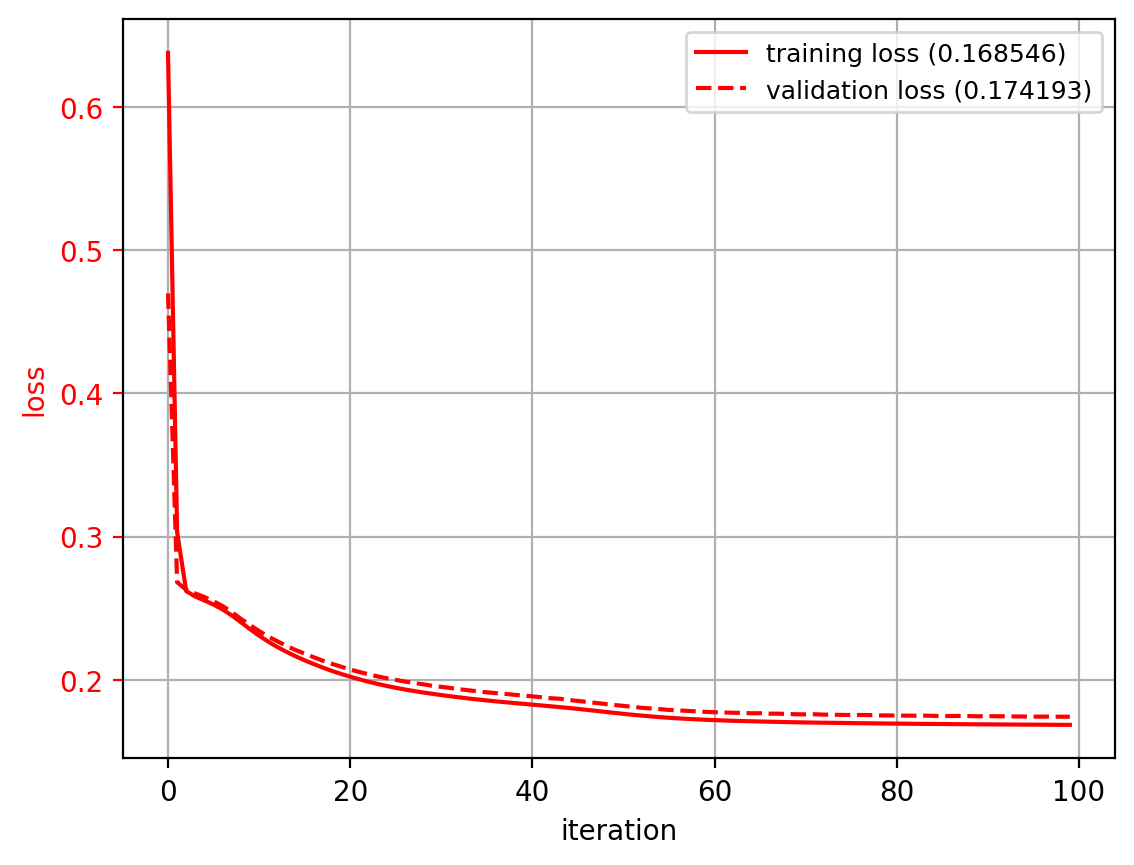

In [16]:
# Plot the training history
plot_history(history)

- Visualize the weights of the hidden layer in E
  - each hidden node activates on a particular structure

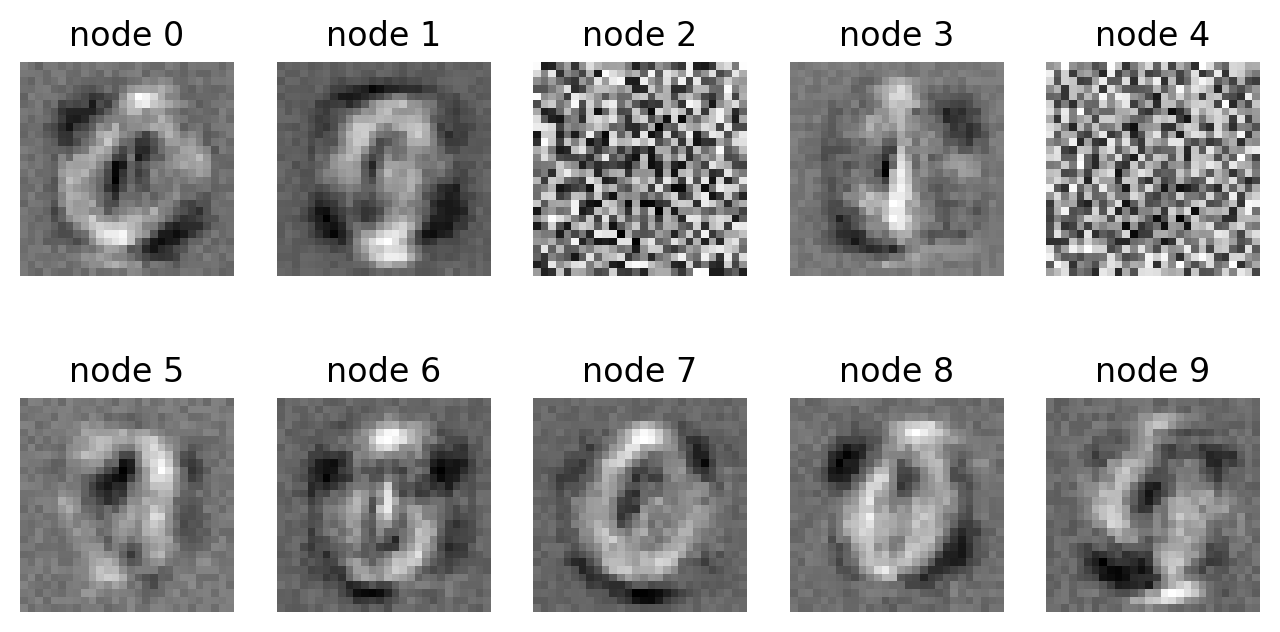

In [17]:
W = model.encoder[0].weight.cpu().numpy()
filter_list = [W[i].reshape((28,28)) for i in range(W.shape[0])]
plt.figure(figsize=(8,4))
show_imgs(filter_list, nc=5, titles="node %d")

- Encode images into low-dim representation.

In [18]:
model.eval()
Z = model.encoder(trainI.flatten(1)).cpu().numpy()
Z.shape

(6000, 10)

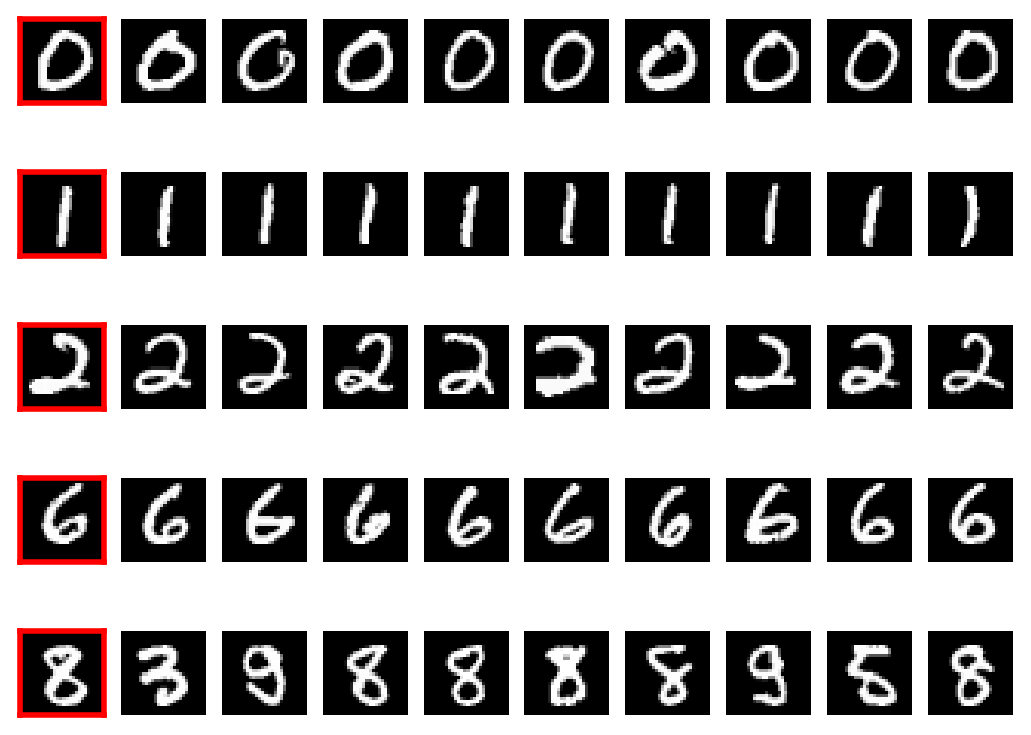

In [19]:
Wlist = []
for ii in [210,4,101,9,294]:
    d = metrics.pairwise.euclidean_distances(Z, [Z[ii]])
    inds = np.argsort(d.ravel())
    for x in inds[0:10]:
        Wlist.append(trainI[x].numpy().reshape((28,28))*255.0)
        
Zfig = plt.figure()
tmp = [1,0,0,0,0,0,0,0,0,0]*5
tmp2 = [0]*50
show_imgs(Wlist, nc=10, highlight_red=tmp, highlight_green=tmp2)
plt.close()

- for the given highlighted red digit
  - show the 9 nearest neighbors in the latent space

In [20]:
def plot_embedding(X, Y, perplexity):
    #IPython.core.display.set_matplotlib_formats("retina") # switch to png since the next figure is complex
    tsne = manifold.TSNE(n_components=2, init='pca', perplexity=perplexity, random_state=11)
    x_pts = tsne.fit_transform(X)
    fig = plt.figure(figsize=(8,8))
    plt.scatter(x_pts[:, 0], x_pts[:, 1], c=Y, s=2, cmap=plt.get_cmap('jet'))
    plt.grid()
    plt.show()
    plt.close()
    #IPython.core.display.set_matplotlib_formats("svg")

- Visualize a t-SNE embedding of the latent-space

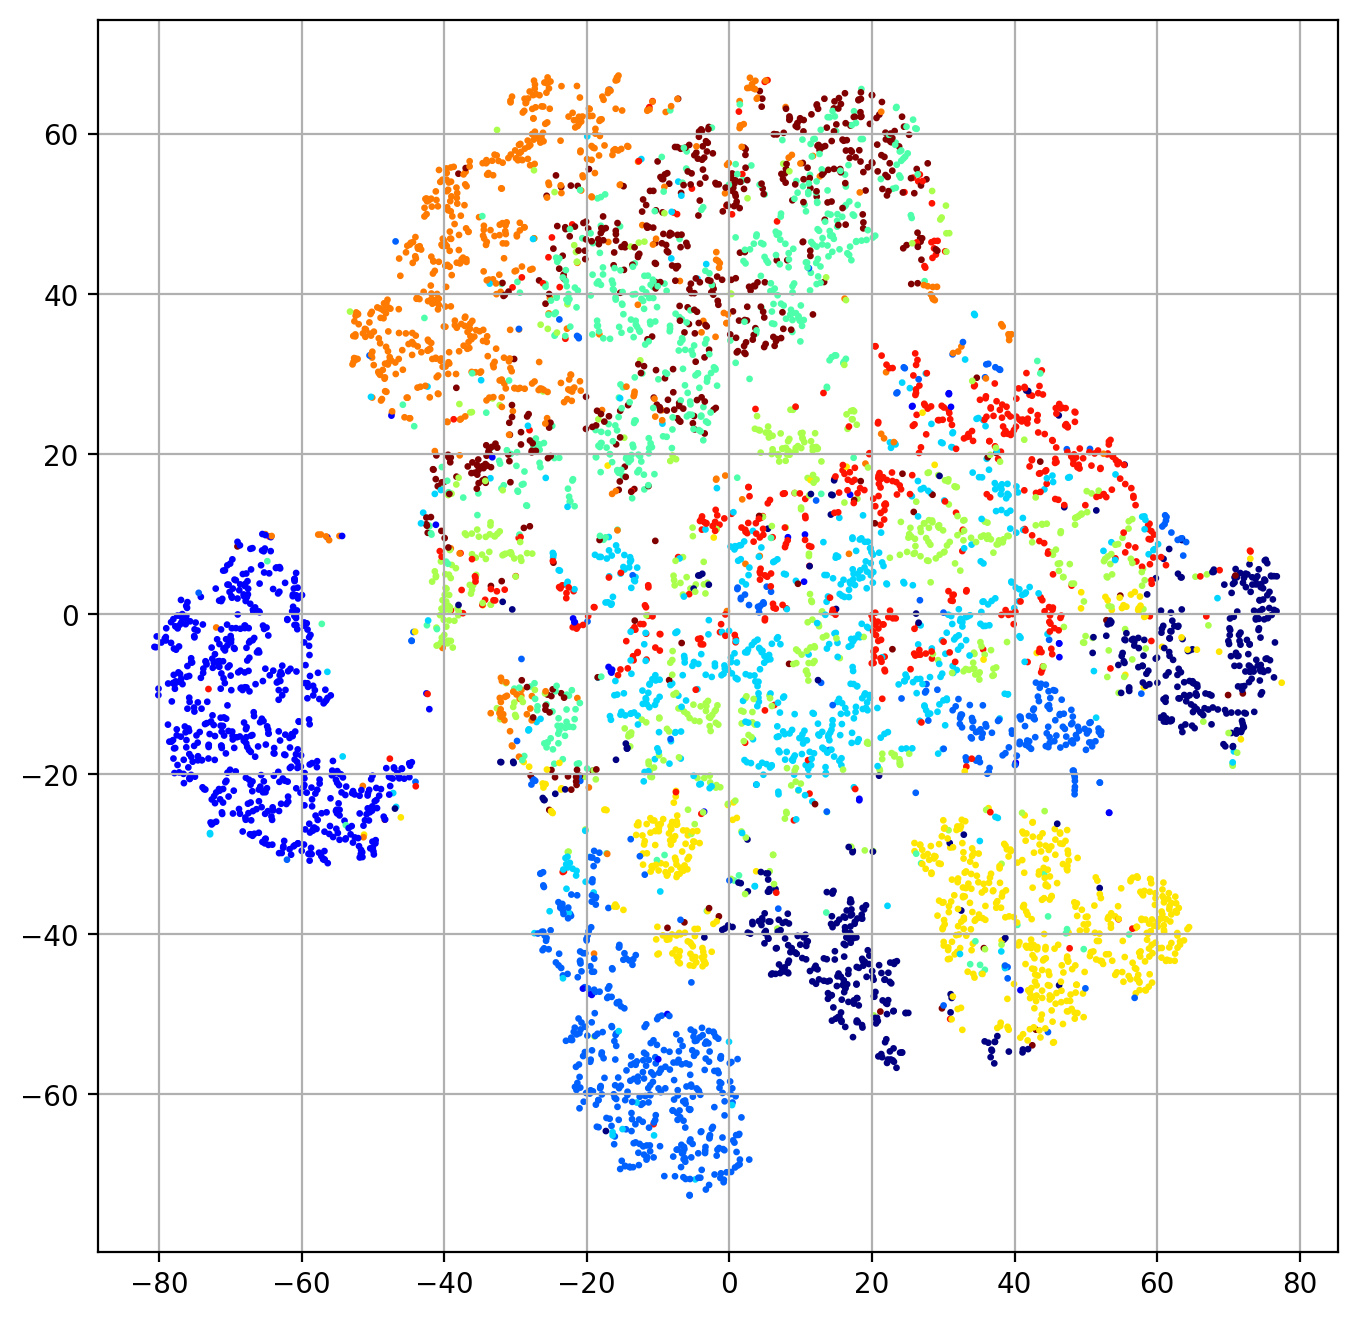

In [21]:
plot_embedding(Z, trainY, perplexity=30.)

- Visualize the reconstruction of the input image

In [22]:
model.eval()
testXrecon = model(testI.flatten(1).to(device))

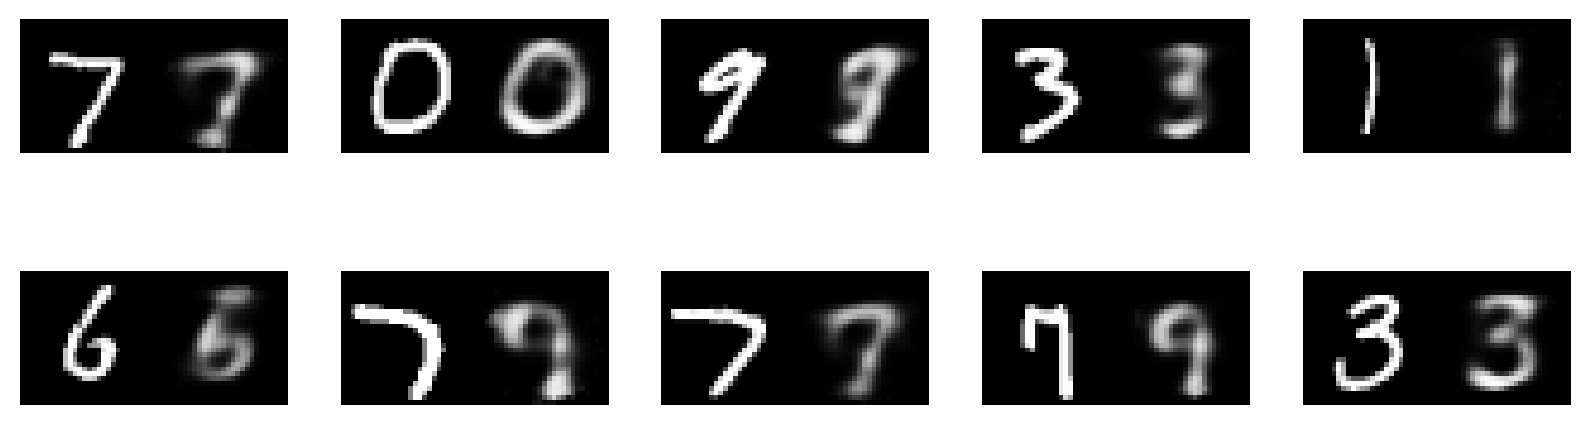

In [23]:
imglist = []
for j,i in enumerate(range(0,100,10)):
    tmp = np.hstack( (testI[i].reshape((28,28))*255.0, testXrecon[i].reshape((28,28)).numpy()*255.0 ))
    imglist.append(tmp)
rfig = plt.figure(figsize=(10,3))
show_imgs(imglist,nc=5)
plt.close()

# Better Representations
- How to encourage better representations in the latent space?
- Two approaches:
  1. Regularize the latent space
    - e.g., using a sparisty-inducing regularizer of the latent vector
    - $L = ||\mathbf{x}-g(f(\mathbf{x}))||^2 + \lambda ||f(\mathbf{x})||_1$
  2. Denoising auto-encoder (DAE)
    - add noise to make the encoder learn more about the data manifold.

# Denoising Autoencoder
- **Idea**: the AE's goal is to minimize $||\mathbf{x}-g(f(\mathbf{x}))||^2$. 
  - the minimum occurs when $g(f(\mathbf{x}))=\mathbf{x}$, i.e., the identity function.
- **Problem**: The network can obtain this arbitrariliy if enough capacity.
  - but without learning anything about the data distribution.

- **Solution**: 
  - Force the AE to learn more about the data by corrupting the inputs.
    - minimize $||\mathbf{x}-g(f(\tilde{\mathbf{x}}))||^2$
    - $\tilde{\mathbf{x}}$ is a corrupted input
      - e.g., adding Gaussian noise, or zeroing some values
  - AE will learn how to "undo" the corruption, which requires learning the structure of the data manifold.
    - allows "code" size to be larger than the input size

# DAE Interpretation (1)
- DAE is learning a vector field from the corrupted $\tilde{\mathbf{x}}$ to the clean $\mathbf{x}$ (the data manifold).

<center><img src="imgs/dae-vf.jpg" width=600></center>

# Example

<center><img src="imgs/dae-vf-eg.png" width=600></center>

# Denoising Autoencoder
- randomly corrupt the input (by setting values to 0)
- implemented by applying Dropout on the inputs.
<center><img src="imgs/dae.png" width=600></center>

In [24]:
# Define the Denoising Autoencoder
class DenoiseAE(DenseAE):
    def __init__(self):
        super(DenoiseAE, self).__init__()
        # Encoder
        self.dropout = nn.Dropout1d(p=0.3)
    
    def forward(self, x):
        encoded = self.encoder(self.dropout(x))
        decoded = self.decoder(encoded)
        return decoded

    def encode_proc(self, x):
        return self.encoder(self.dropout(x))

- Encoder and decoder subnetworks

In [25]:
# Initialize random seed
torch.manual_seed(4487)
random.seed(4487)
np.random.seed(4487)
if torch.cuda.is_available():
    torch.cuda.manual_seed(4487)
    torch.backends.cudnn.deterministic = True

In [26]:
# Create model instance
model = DenoiseAE()

# Print model architecture
print(model)
summarize_layer_parameters(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

DenoiseAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=784, bias=True)
    (1): Sigmoid()
  )
  (dropout): Dropout1d(p=0.3, inplace=False)
)
+------------------+------------+
|   Module Name    | Parameters |
+------------------+------------+
| encoder.0.weight |    7840    |
|  encoder.0.bias  |     10     |
| decoder.0.weight |    7840    |
|  decoder.0.bias  |    784     |
+------------------+------------+

Total Trainable Parameters: 16474

Total Un-Trainable Parameters: 0
Using device: cpu


- Full auto-encoder network
  - Composed of the encoder and decoder models

- Compile the model

In [27]:
# Compile the network (equivalent in PyTorch)
optimizer = optim.SGD(model.parameters(), lr=0.15, momentum=0.9, nesterov=True)
early_stopping = EarlyStopping(min_delta=0.0001,patience=5)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, early_stopping, epochs=100)

Epoch 1/100:   Train Loss: 0.663139   Val Loss: 0.585272
Epoch 2/100:   Train Loss: 0.415039   Val Loss: 0.277693
Epoch 3/100:   Train Loss: 0.292573   Val Loss: 0.261932
Epoch 4/100:   Train Loss: 0.268711   Val Loss: 0.257069
Epoch 5/100:   Train Loss: 0.259757   Val Loss: 0.254075
Epoch 6/100:   Train Loss: 0.254888   Val Loss: 0.251974
Epoch 7/100:   Train Loss: 0.251477   Val Loss: 0.249859
Epoch 8/100:   Train Loss: 0.249086   Val Loss: 0.247837
Epoch 9/100:   Train Loss: 0.246774   Val Loss: 0.245613
Epoch 10/100:   Train Loss: 0.244812   Val Loss: 0.243266
Epoch 11/100:   Train Loss: 0.242597   Val Loss: 0.240533
Epoch 12/100:   Train Loss: 0.240303   Val Loss: 0.237757
Epoch 13/100:   Train Loss: 0.238199   Val Loss: 0.235045
Epoch 14/100:   Train Loss: 0.235877   Val Loss: 0.232279
Epoch 15/100:   Train Loss: 0.233393   Val Loss: 0.229648
Epoch 16/100:   Train Loss: 0.231749   Val Loss: 0.227419
Epoch 17/100:   Train Loss: 0.229605   Val Loss: 0.225069
Epoch 18/100:   Train L

- Fit the model

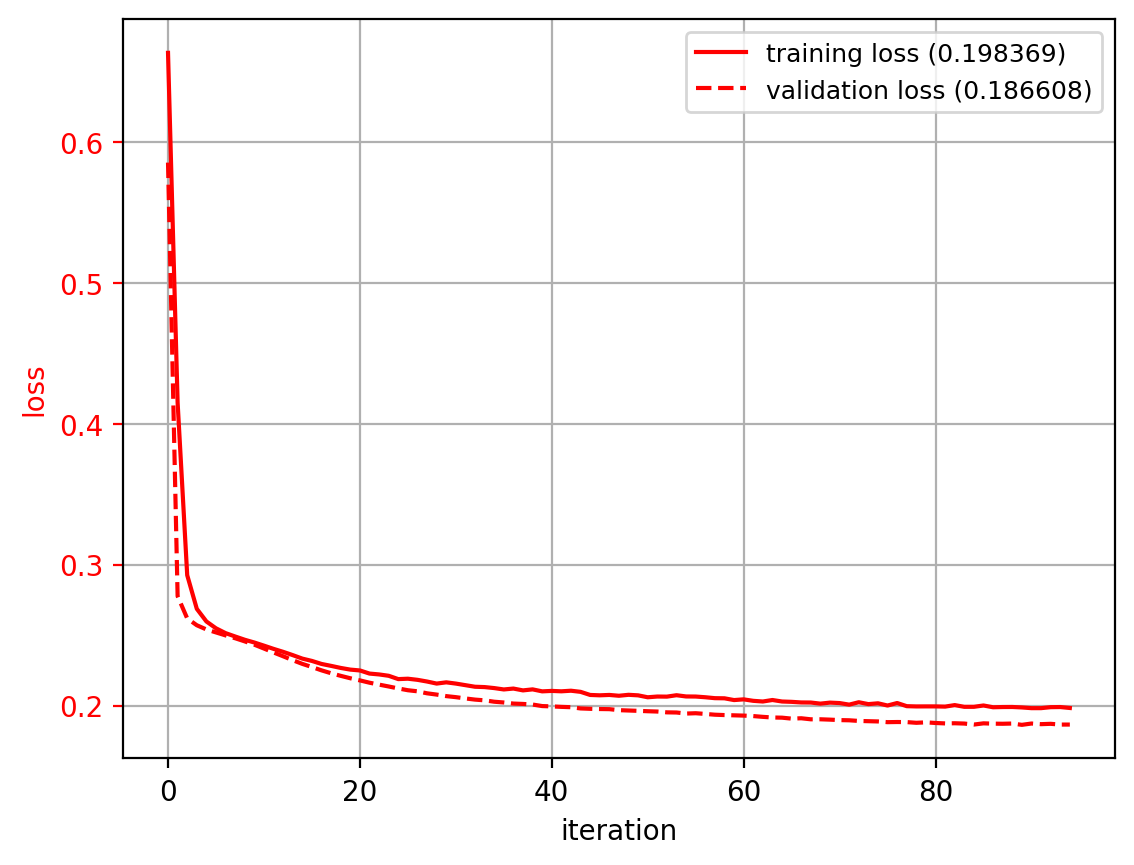

In [28]:
plot_history(history)

- Encode images into low-dim representation.
  - Note: at test time, Dropout layers do not add noise.

In [29]:
model.eval()
Z = model.encoder(trainI.flatten(1)).cpu().numpy()
Z.shape

(6000, 10)

- Visualize the nearby neighbors in the low-dim representation.
  - each row represents one set of neighbors

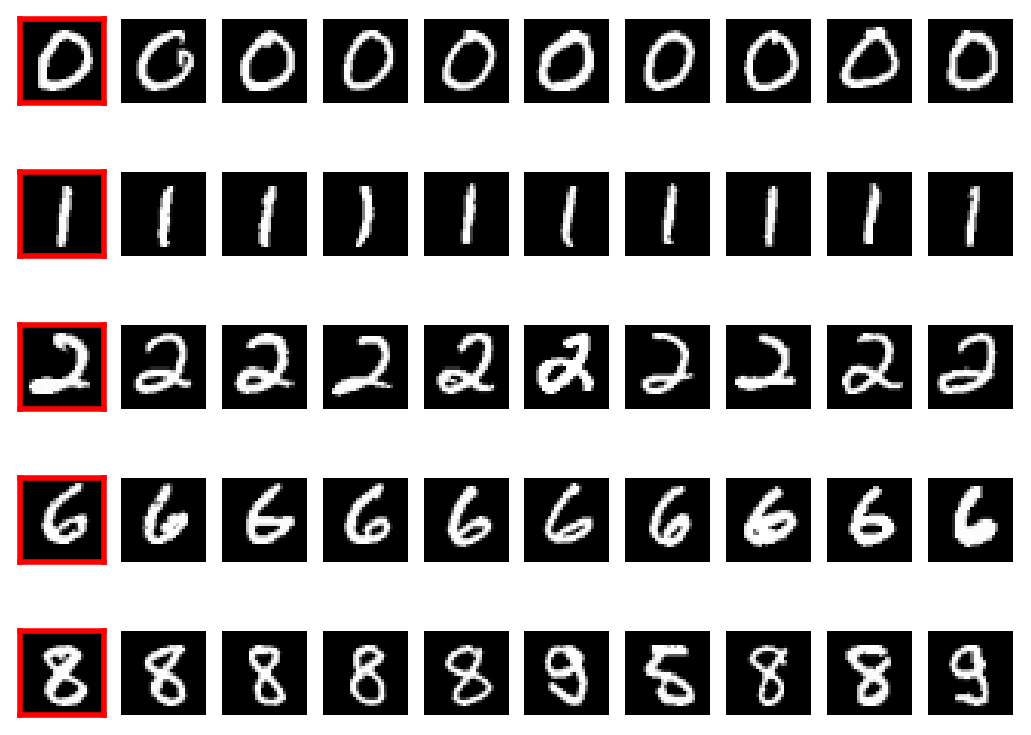

In [30]:
Wlist = []
for ii in [210,4,101,9,294]:
    d = metrics.pairwise.euclidean_distances(Z, [Z[ii]])
    inds = np.argsort(d.ravel())
    for x in inds[0:10]:
        Wlist.append(trainI[x].numpy().reshape((28,28))*255.0)
        
tmp = [1,0,0,0,0,0,0,0,0,0]*5
tmp2 = [0]*50
Zfig = plt.figure()
show_imgs(Wlist, nc=10, highlight_red=tmp, highlight_green=tmp2)
plt.close()

- Visualize the weights of the hidden layer that generate codes
  - each hidden node activates on a particular structure

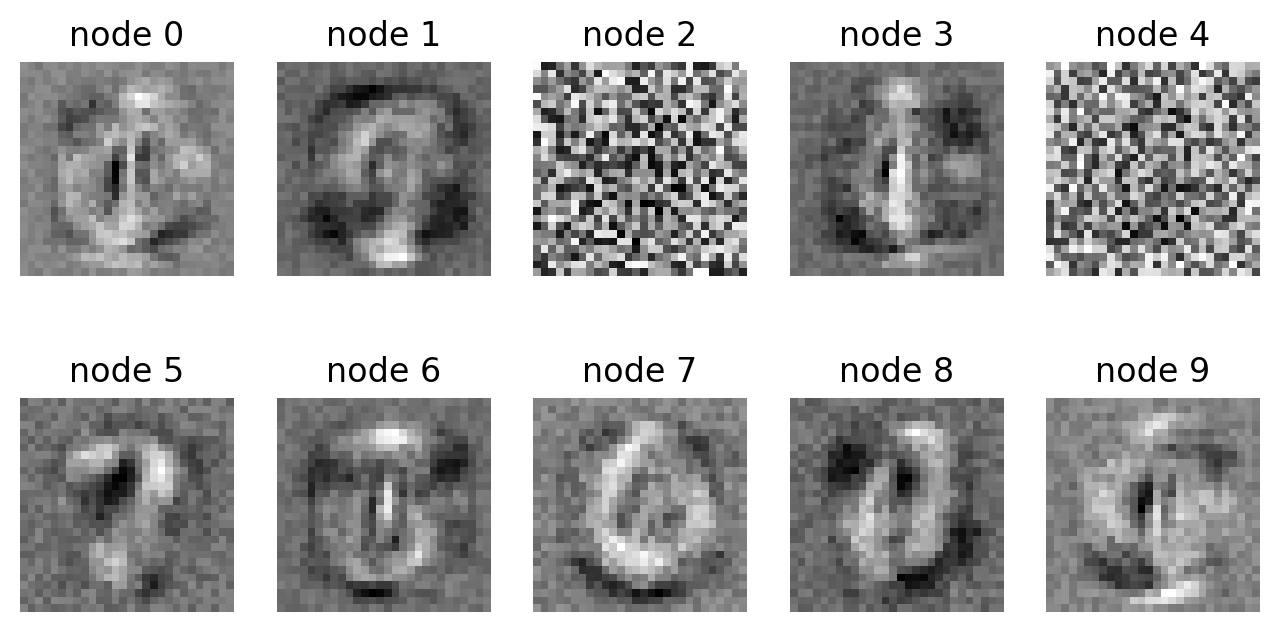

In [31]:
W = model.encoder[0].weight.cpu().numpy()
filter_list = [W[i].reshape((28,28)) for i in range(W.shape[0])]
plt.figure(figsize=(8,4))
show_imgs(filter_list, nc=5, titles="node %d")

- Visualize the weights that project the code into an image
  - the image structures match those of the encoder, but are smoother.

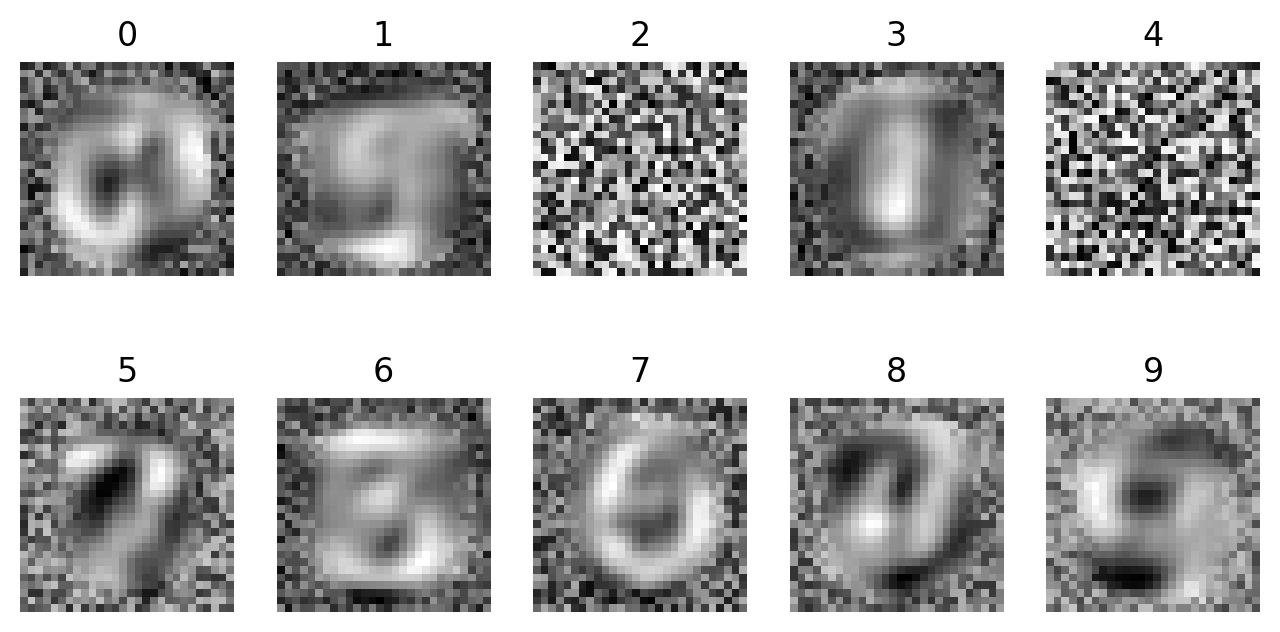

In [32]:
W = model.decoder[0].weight.T.cpu().numpy()
filter_list = [W[i,:].reshape((28,28)) for i in range(W.shape[0])]
plt.figure(figsize=(8,4))
show_imgs(filter_list, nc=5, titles="%d")

- Visualize the reconstruction of the input image

In [33]:
model.eval()
testXrecon = model(testI.flatten(1).to(device))

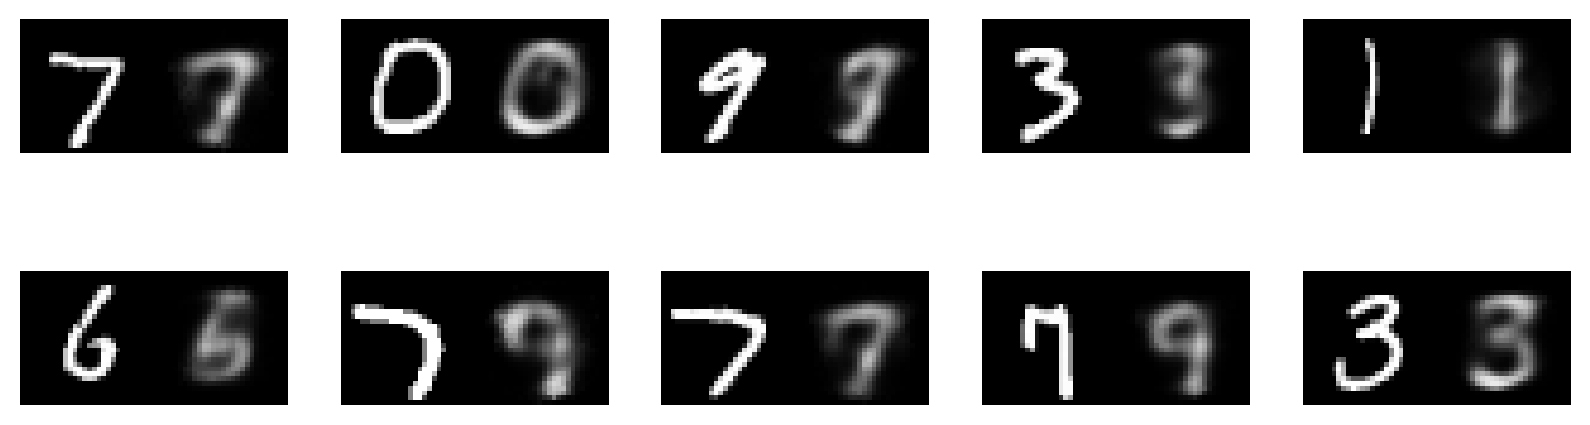

In [34]:
imglist = []
for j,i in enumerate(range(0,100,10)):
    tmp = np.hstack( (testI[i].reshape((28,28))*255.0, testXrecon[i].reshape((28,28)).numpy()*255.0 ))
    imglist.append(tmp)
rfig = plt.figure(figsize=(10,3))
show_imgs(imglist,nc=5)
plt.close()

- Corrupt the input image and encode-decode
  - performs "denoising" of the input

In [35]:
noisytest = testI * np.random.binomial(n=1,p=1-0.3,size=testI.shape)
testXrecon = model(noisytest.float().flatten(1).to(device))

/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_75225/2601454893.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  noisytest = testI * np.random.binomial(n=1,p=1-0.3,size=testI.shape)


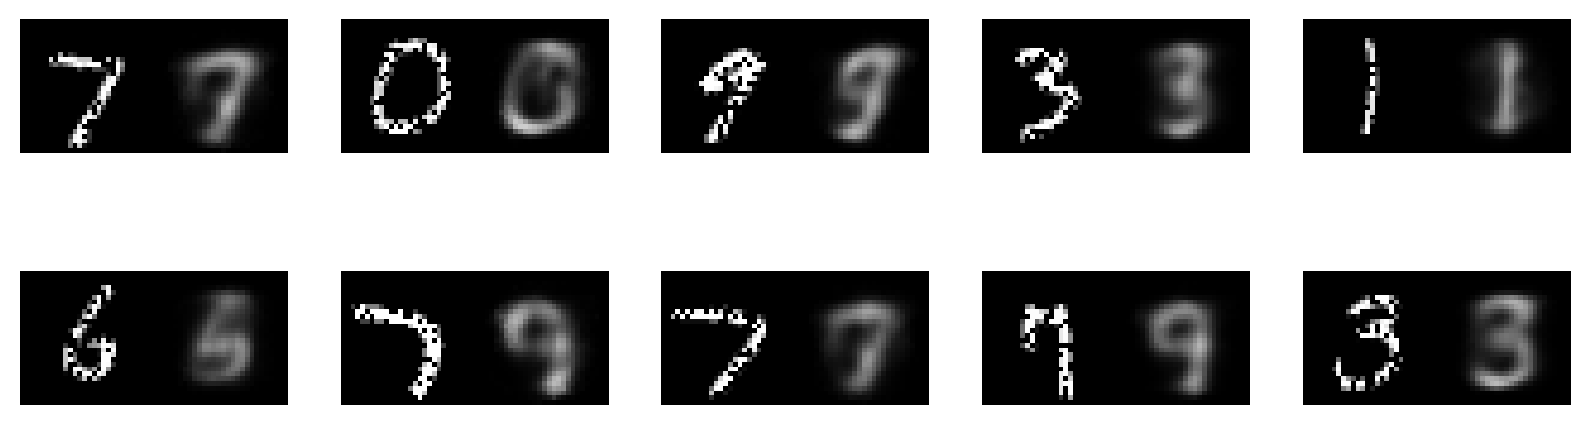

In [36]:
imglist = []
for j,i in enumerate(range(0,100,10)):
    tmp = np.hstack( (noisytest[i].reshape((28,28)).numpy()*255.0, testXrecon[i].reshape((28,28)).numpy()*255.0 ))
    imglist.append(tmp)
rfig = plt.figure(figsize=(10,3))
show_imgs(imglist,nc=5)
plt.close()

# DAE Interpretation 2
- Learning a reconstruction distribution $p_{\mathrm{recon}}(\mathbf{x}|\tilde{\mathbf{x}})$
- Generative process:
  1. sample training example $\mathbf{x}$
  2. corrupt $\tilde{\mathbf{x}} \sim C(\tilde{\mathbf{x}}|\mathbf{x})$
  3. use $(\tilde{\mathbf{x}},\mathbf{x})$ as a training example to estimate
  $$\begin{aligned}p_{\mathrm{recon}}(\mathbf{x}|\tilde{\mathbf{x}}) &= p_{\mathrm{decoder}}(\mathbf{x}|\mathbf{z}), \\ \mathbf{z} &= f(\tilde{\mathbf{x}})\end{aligned}$$

- Assume $p_{\mathrm{decoder}}(\mathbf{x}|\mathbf{z})$ is Gaussian:
  - Note that $\log p_{\mathrm{decoder}}(\mathbf{x}|\mathbf{z}) = -||\mathbf{x}-g(\mathbf{z})||^2$ (negative MSE loss)
- Minimize the loss over the training distribution
  - $\sum_i ||\mathbf{x}_i - g(f(\tilde{\mathbf{x}}_i))||^2$
- is equivalent to maximizing the expected log probability
$$\mathbb{E}_{\mathbf{x}\sim p_{\mathrm{data}}(\mathbf{x})} \mathbb{E}_{\tilde{\mathbf{x}}\sim C(\tilde{\mathbf{x}}|\mathbf{x})} [\log p_{\mathrm{decoder}}(\mathbf{x}|\mathbf{z}=f(\tilde{\mathbf{x}}))]$$
  - expectation is over the data and the corruption.

# Convolutional Auto-Encoder
- Encoder - a standard CNN (w/o classifier)
  - Extract a feature map

- Decoder
  - the opposite architecture
  - Replace maxpooling with upsampling 

In [37]:
class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # (batch_size, 16, 28, 28)
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),      # (batch_size, 16, 14, 14)
            
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),  # (batch_size, 8, 14, 14)
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),      # (batch_size, 8, 7, 7)
            
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1),   # (batch_size, 8, 7, 7)
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1),      # (batch_size, 8, 4, 4) - Encoded representation
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1),   # (batch_size, 8, 4, 4)
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),           # (batch_size, 8, 8, 8)
            
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1),   # (batch_size, 8, 8, 8)
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),           # (batch_size, 8, 16, 16)
            
            # Note: Adjusted to match dimensions - no padding to reduce from 16x16 to 14x14
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=0),  # (batch_size, 16, 14, 14)
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='nearest'),           # (batch_size, 16, 28, 28)
            
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),  # (batch_size, 1, 28, 28)
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

- Encoder and Decoders

In [38]:
# Create model instance
model = ConvAE()

# Print model architecture
print(model)
summarize_layer_parameters(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Upsample(scale_factor=2.0, mode='nearest')
    (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): Upsample(scale_factor=2.0, mode='nearest')
    (6): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU(inp

In [39]:
# Prepare data & Create Dataloader
batch_size = 128
train_dataset = TensorDataset(vtrainI, vtrainY)
valid_dataset = TensorDataset(validI, validY)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Compile the network (equivalent in PyTorch)
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters())
early_stopping = EarlyStopping(min_delta=0.0001,patience=5)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, early_stopping, epochs=100)

Epoch 1/100:   Train Loss: 0.580738   Val Loss: 0.441278
Epoch 2/100:   Train Loss: 0.369752   Val Loss: 0.290536
Epoch 3/100:   Train Loss: 0.236372   Val Loss: 0.213465
Epoch 4/100:   Train Loss: 0.200582   Val Loss: 0.195443
Epoch 5/100:   Train Loss: 0.185938   Val Loss: 0.183953
Epoch 6/100:   Train Loss: 0.175762   Val Loss: 0.174883
Epoch 7/100:   Train Loss: 0.167399   Val Loss: 0.167010
Epoch 8/100:   Train Loss: 0.159727   Val Loss: 0.160395
Epoch 9/100:   Train Loss: 0.153644   Val Loss: 0.154492
Epoch 10/100:   Train Loss: 0.148495   Val Loss: 0.149854
Epoch 11/100:   Train Loss: 0.144461   Val Loss: 0.145233
Epoch 12/100:   Train Loss: 0.141093   Val Loss: 0.142052
Epoch 13/100:   Train Loss: 0.137806   Val Loss: 0.139236
Epoch 14/100:   Train Loss: 0.135250   Val Loss: 0.136462
Epoch 15/100:   Train Loss: 0.133388   Val Loss: 0.134951
Epoch 16/100:   Train Loss: 0.131438   Val Loss: 0.132702
Epoch 17/100:   Train Loss: 0.129716   Val Loss: 0.132089
Epoch 18/100:   Train L

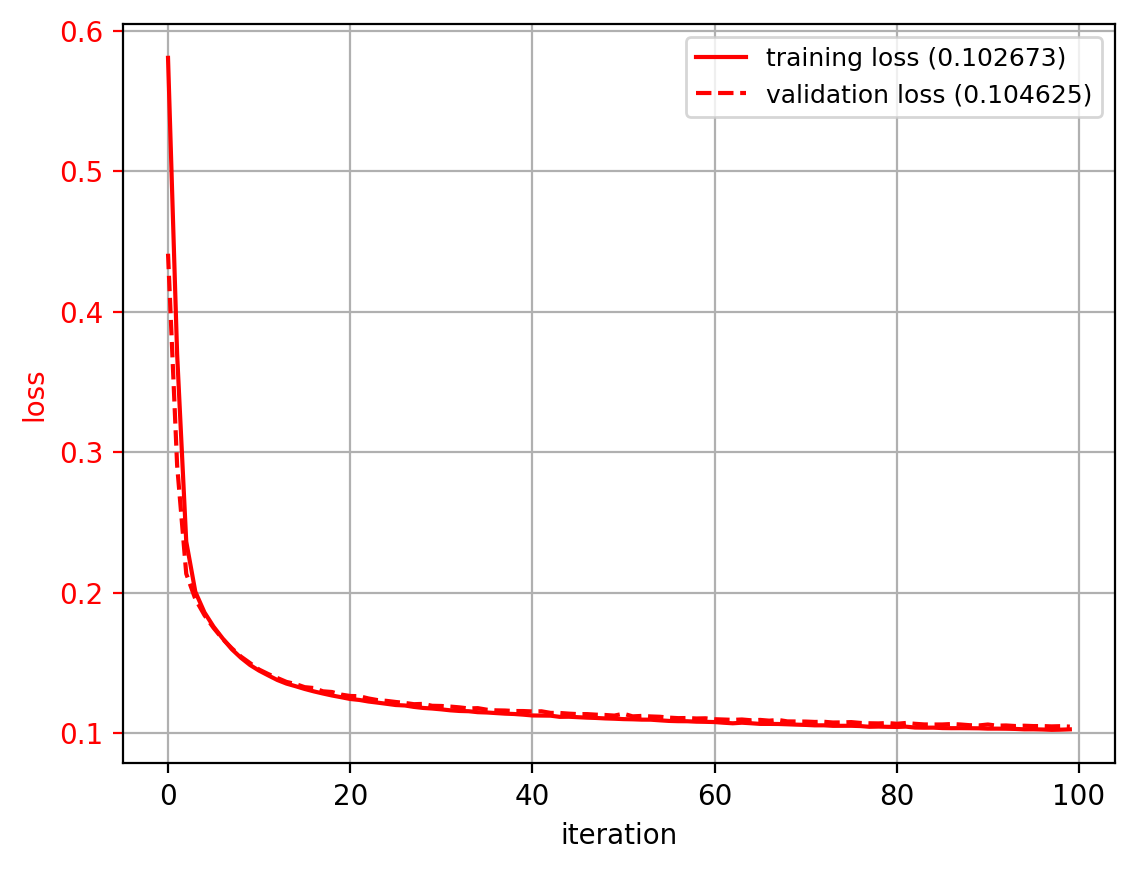

In [40]:
plot_history(history)

- Visualize the latent space

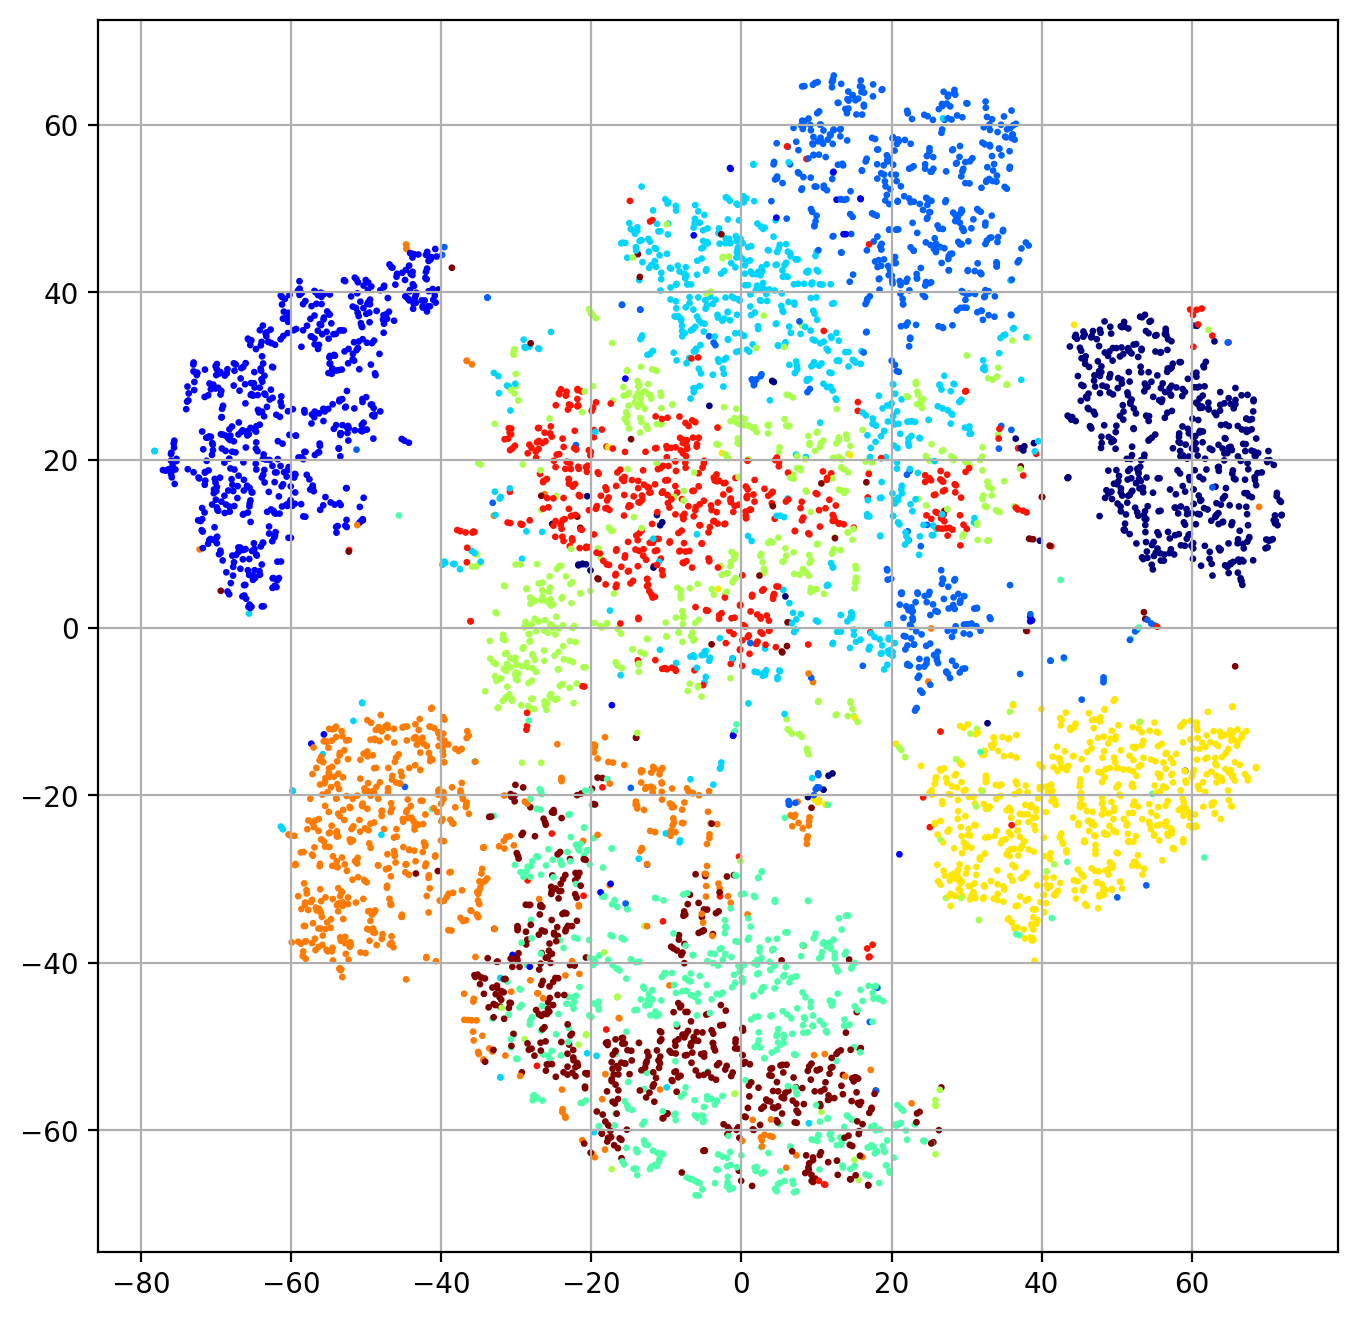

In [41]:
model.eval()
Z = model.encoder(trainI).flatten(1).cpu().numpy()
plot_embedding(Z, trainY, perplexity=30.)

- Encode and reconstruct an image

In [42]:
testIrecon = model(testI.float().to(device))

- Better visualization

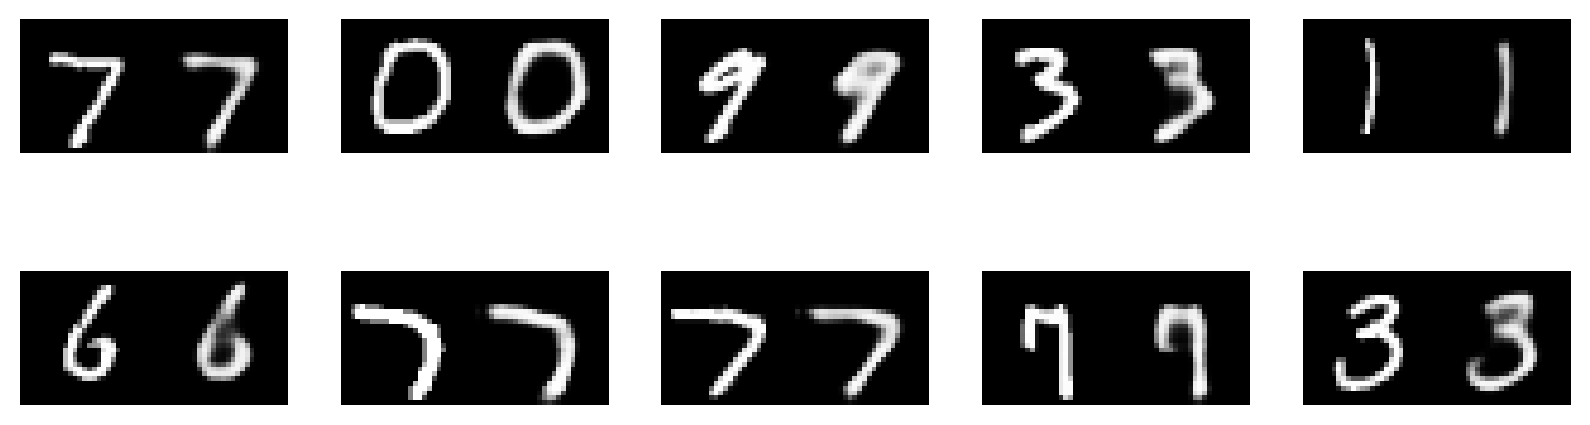

In [43]:
imglist = []
for j,i in enumerate(range(0,100,10)):
    tmp = np.hstack( (testI[i].reshape((28,28)).numpy()*255.0, testIrecon[i].reshape((28,28)).numpy()*255.0 ))
    imglist.append(tmp)
rfig = plt.figure(figsize=(10,3))
show_imgs(imglist,nc=5)
plt.close()

- Traverse the latent space
  - Sample points: $$\mathbf{z}_1 = f(\mathbf{x}_1), \mathbf{z}_2 = f(\mathbf{x}_2)$$
  - interpolate: $$\mathbf{\hat{z}} = (1-\alpha) \mathbf{z}_1 + \alpha \mathbf{z}_2, 0\leq \alpha\leq 1$$
  - reconstruct: $$\mathbf{\hat{x}} = g(\mathbf{\hat{z}})$$
- Change a 7 into a 1

In [44]:
def Xinterp(X,sp=10):
    alpha = np.linspace(0,1,sp).reshape((sp,)+(np.ndim(X)-1)*(1,))
    Xint = X[0,:]*(1-alpha) + X[1,:]*alpha
    return Xint

In [45]:
inds = [0,40]
X = model.encoder(testI[inds,:].float().to(device))
Xd = model.decoder(Xinterp(X).float().to(device))

/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_75225/1193900626.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Xint = X[0,:]*(1-alpha) + X[1,:]*alpha


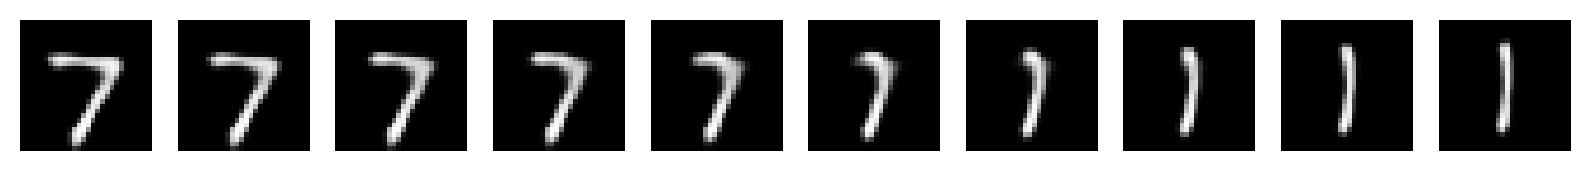

In [46]:
rfig = plt.figure(figsize=(10,3))
show_imgs(Xd.reshape((10,28,28)).numpy()*255.0,nc=10)
plt.close()

- Traverse the latent space between a 7, 1, 9, and 4
  - captures shapes in between

In [47]:
def Xinterp2(X, sp=10):
    Xtbl = Xinterp(X[[0,2],:], sp=sp)
    Xtbr = Xinterp(X[[1,3],:], sp=sp)
    
    # interpolate inbetween    
    Xall = torch.zeros((sp*sp,) + Xtbl.shape[1:])
    for i in range(sp):
        tmpX = torch.concat((Xtbl[i,:].unsqueeze(0), Xtbr[i,:].unsqueeze(0)), dim=0)
        Xall[sp*i:sp*(i+1),:] = Xinterp(tmpX, sp=sp)
    return Xall

/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_75225/1193900626.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Xint = X[0,:]*(1-alpha) + X[1,:]*alpha


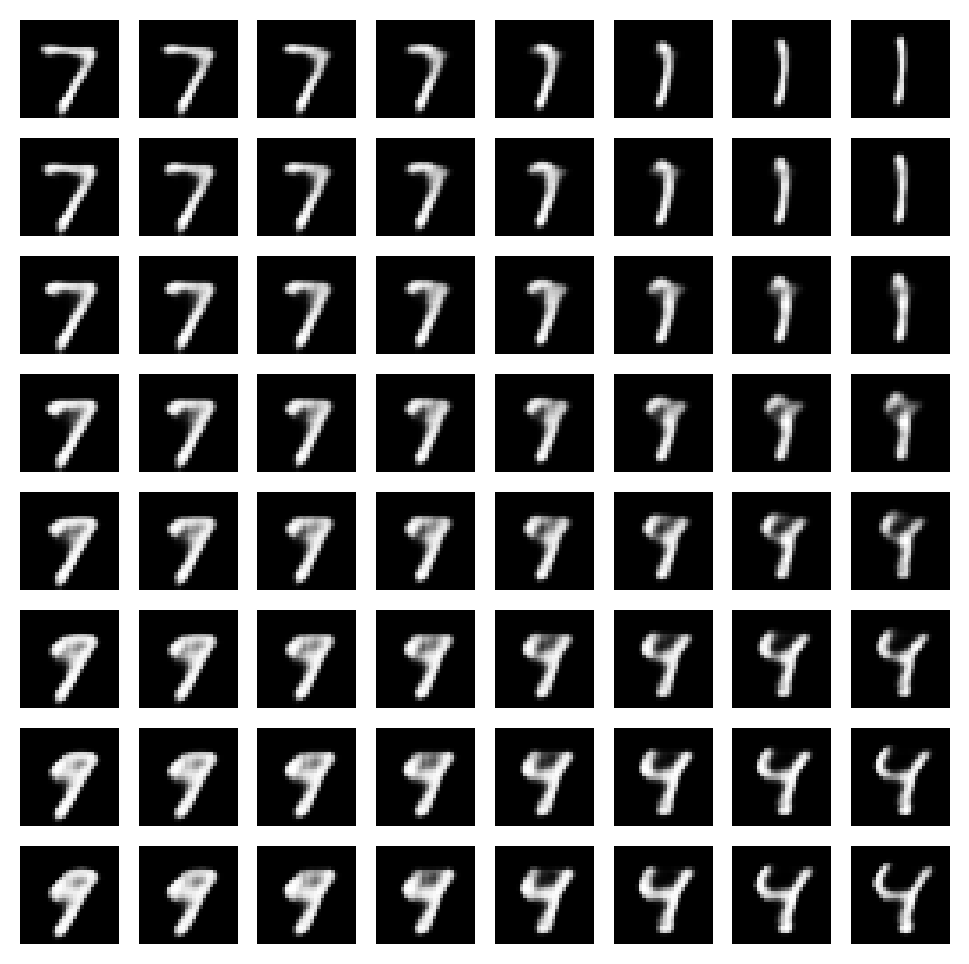

In [48]:
inds = [0, 40, 20, 6]
X = model.encoder(testI[inds,:].float().to(device))
Xd = model.decoder(Xinterp2(X, sp=8).float().to(device))
rfig = plt.figure(figsize=(6,6))
show_imgs(Xd.reshape((64,28,28)).numpy()*255.0,nc=8)
plt.close()

- Traverse the latent space between different 7s
  - captures different shapes of 7

/var/folders/v0/s4761j_n3z7_f651dfw62m5w0000gn/T/ipykernel_75225/1193900626.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Xint = X[0,:]*(1-alpha) + X[1,:]*alpha


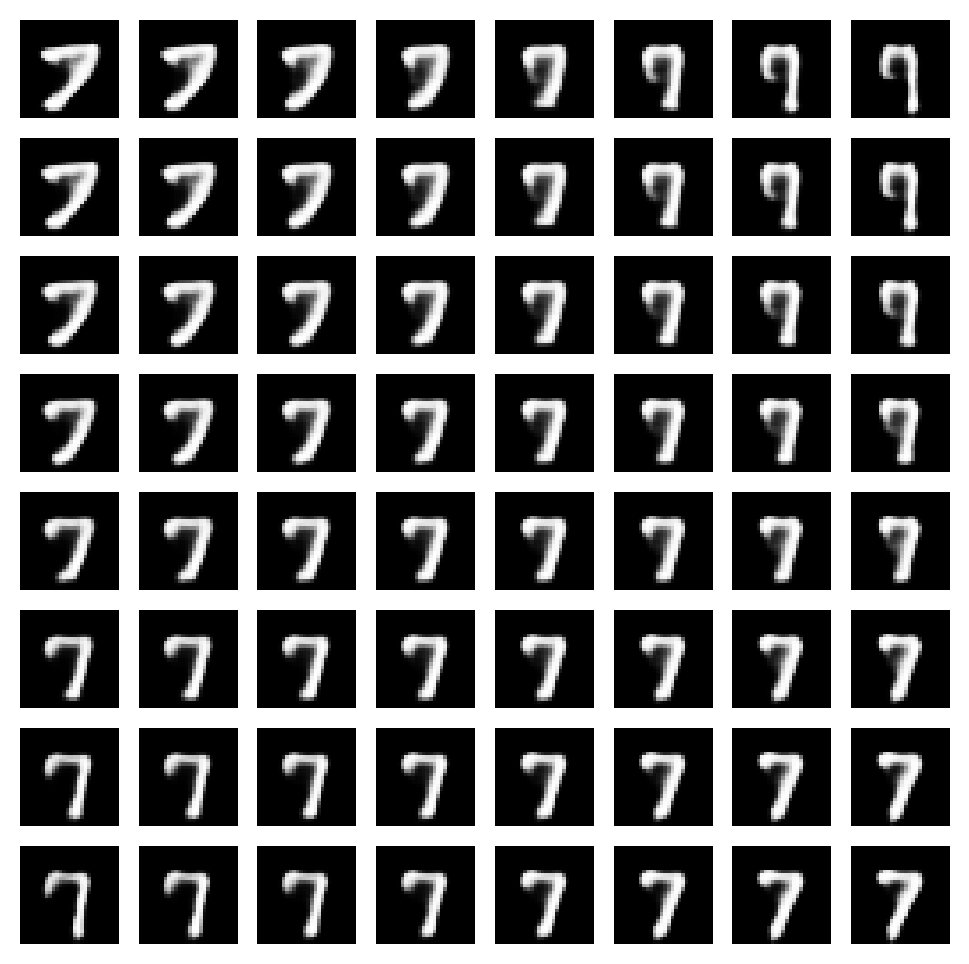

In [49]:
mydigits = np.where(testY==7)[0]
inds = mydigits[10:14]
X = model.encoder(testI[inds,:].float().to(device))
Xd = model.decoder(Xinterp2(X,sp=8).float().to(device))
rfig = plt.figure(figsize=(6,6))
show_imgs(Xd.reshape((64,28,28)).numpy()*255.0,nc=8)
plt.close()

# Masked Autoencoder (MAE)
- Combine ViT with auto-encoder for self-supervised representation learning.
  - encode subset  of input patches (mask out 75%)
  - decode encoded & masked patches to reconstruct the image
- Pre-train on IN1k (w/o labels)
  
<center><img src="imgs/mae.png" width=600></center>

- Fine-tune on IN1k classification task 
  - better than supervised pre-training of ViT with IN1k
  - but worse than supervised pre-training with large-scale data (JFT)
 
<center><img src="imgs/mae-train.png" width=600></center>

# Semantic Segmentation
- Label each pixel in the image with a category label.

<img src="imgs/semseg.png" width=600>

# Fully-convolutional network (FCN)
- learns mapping from input image to output segmentation
  - encoder/decoder structure similar to AE.
  - middle contains the low-dim representation.

<img src="imgs/fcn.png" width=800>

# U-net: More sophisticated FCN
- Idea: concatenate higher-resolution features when upsampling
  - Better localize boundaries.
  - Mix high-level and low-level features.
<img src="imgs/unet.png" width=600>
